In [18]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(os.path.join('..', 'ml-backend'))

from utils.feature_extractor import extract_features, extract_features_batch

print("Import berhasil!")

Import berhasil!


In [19]:
df_phishing_raw = pd.read_csv('../dataset/phishing_urls.csv')

print("Jumlah baris:", len(df_phishing_raw))
print("Kolom yang ada:", df_phishing_raw.columns.tolist())
print(df_phishing_raw.head(3))

Jumlah baris: 57103
Kolom yang ada: ['phish_id', 'url', 'phish_detail_url', 'submission_time', 'verified', 'verification_time', 'online', 'target']
   phish_id                                        url  \
0   9397334     http://allegrolokalne.pl-590120421.lol   
1   9397332           http://allegro.pl-5903241241.lol   
2   9397331  http://allegro-lokalnie.pl-5903241241.lol   

                                    phish_detail_url  \
0  http://www.phishtank.com/phish_detail.php?phis...   
1  http://www.phishtank.com/phish_detail.php?phis...   
2  http://www.phishtank.com/phish_detail.php?phis...   

             submission_time verified          verification_time online  \
0  2026-04-19T07:56:30+00:00      yes  2026-04-19T08:03:15+00:00    yes   
1  2026-04-19T07:56:25+00:00      yes  2026-04-19T08:03:15+00:00    yes   
2  2026-04-19T07:56:15+00:00      yes  2026-04-19T08:03:15+00:00    yes   

    target  
0  Allegro  
1  Allegro  
2  Allegro  


In [ ]:
df_phishing = pd.DataFrame({
    'url'   : df_phishing_raw['url'],
    'label' : 1
})

df_phishing = df_phishing.dropna().drop_duplicates()

df_phishing = df_phishing.head(5000)

print(f"Dataset phishing: {len(df_phishing)} URL")

Dataset phishing: 3000 URL


In [21]:
df_alexa_raw = pd.read_csv(
    '../dataset/top-1m.csv',
    header=None,
    names=['rank', 'domain']
)

df_legitimate = pd.DataFrame({
    'url'   : 'https://' + df_alexa_raw['domain'],
    'label' : 0
})

df_legitimate = df_legitimate.head(5000)

print(f"Dataset legitimate: {len(df_legitimate)} URL")

Dataset legitimate: 5000 URL


In [ ]:
import numpy as np

KEYWORD_SLOT = [
    'slotgacor', 'slot-gacor', 'gacorslot', 'slot777', 'slot88',
    'slotmaxwin', 'slot-maxwin', 'bocoran-slot', 'rtp-slot',
    'slot-online', 'slot-bonus', 'slot-pragmatic', 'slot-pgsoft',
    'slot-zeus', 'slot-olympus', 'gates-of-olympus', 'sweet-bonanza',
    'mahjong-ways', 'starlight-princess', 'slot-scatter',
    'slot-jackpot', 'gacor-slot', 'maxwin-slot', 'slot-terbaru',
    'slot-deposit-dana', 'slot-deposit-pulsa', 'slot-ovo',
    'pola-slot-gacor', 'info-slot-gacor', 'bocoran-slot-gacor',
    'rtp-slot-gacor', 'slot-gacor-hari-ini', 'slot-gacor-malam-ini',
]

KEYWORD_TOGEL = [
    'togel', 'togelonline', 'togel4d', 'bandar-togel', 'agen-togel',
    'togel-singapore', 'togel-hongkong', 'togel-sydney', 'togel-macau',
    'prediksi-togel', 'angka-jitu', 'bocoran-togel', 'togel-resmi',
    'pasang-togel', 'togel-hari-ini', 'result-togel', 'keluaran-togel',
    'live-draw-togel', 'togel-online', 'data-togel',
]

KEYWORD_CASINO = [
    'casino-online', 'live-casino', 'casino-indonesia', 'casino-bonus',
    'baccarat-online', 'roulette-online', 'casino88', 'casino365',
    'casino-terpercaya', 'casino-deposit', 'casino-bet',
]

KEYWORD_POKER = [
    'poker-online', 'poker-indonesia', 'poker-uang-asli',
    'dominoqq', 'bandarq', 'ceme-online', 'poker88', 'idn-poker',
    'capsa-susun', 'sakong-online', 'poker-terpercaya',
]

KEYWORD_SBOBET = [
    'sbobet', 'sbobet88', 'agen-sbobet', 'sbobet-indonesia',
    'judi-bola', 'taruhan-bola', 'mix-parlay', 'bandar-bola',
    'judi-parlay', 'bola-online', 'sportsbook', 'maxbet', 'ibcbet',
]

KEYWORD_UMUM = [
    'judi-online', 'judionline', 'judi-slot', 'agen-judi',
    'bandar-judi', 'judi-deposit-pulsa', 'bonus-new-member',
    'bonus-100', 'freebet', 'rtp-live', 'rtp-gacor',
    'scatter-hitam', 'scatter-gacor', 'pola-gacor', 'maxwin', 'judol',
]

TLD_JUDOL = [
    '.com', '.net', '.xyz', '.online', '.site',
    '.info', '.club', '.live', '.top', '.vip',
]

SUFFIX = ['', '88', '77', '99', '168', '365', '2024', '4d', '138']
PROTOCOL = ['http://', 'https://']

def generate_gambling_urls(keywords, seed=42):
    np.random.seed(seed)
    urls = set()

    for kw in keywords:
        for tld in TLD_JUDOL:
            for proto in PROTOCOL:
                urls.add(f"{proto}{kw}{tld}")

        for suffix in SUFFIX:
            tld   = np.random.choice(TLD_JUDOL)
            proto = np.random.choice(PROTOCOL)
            urls.add(f"{proto}{kw}{suffix}{tld}")

    return list(urls)

np.random.seed(99)

urls_slot   = generate_gambling_urls(KEYWORD_SLOT,   seed=42)
urls_togel  = generate_gambling_urls(KEYWORD_TOGEL,  seed=43)
urls_casino = generate_gambling_urls(KEYWORD_CASINO, seed=44)
urls_poker  = generate_gambling_urls(KEYWORD_POKER,  seed=45)
urls_sbobet = generate_gambling_urls(KEYWORD_SBOBET, seed=46)
urls_umum   = generate_gambling_urls(KEYWORD_UMUM,   seed=47)

semua_url_judi = list(set(
    urls_slot + urls_togel + urls_casino +
    urls_poker + urls_sbobet + urls_umum
))
np.random.shuffle(semua_url_judi)

TARGET_JUDI = 5000
semua_url_judi = semua_url_judi[:TARGET_JUDI]

df_gambling = pd.DataFrame({
    'url'  : semua_url_judi,
    'label': 2
})

df_gambling[['url']].rename(columns={'url':'url'}).assign(
    kategori='judi_online'
).to_csv('../dataset/gambling_urls.csv', index=False)

print(f"Slot     : {len(urls_slot)} URL")
print(f"Togel    : {len(urls_togel)} URL")
print(f"Casino   : {len(urls_casino)} URL")
print(f"Poker    : {len(urls_poker)} URL")
print(f"Sbobet   : {len(urls_sbobet)} URL")
print(f"Umum     : {len(urls_umum)} URL")
print(f"\nTotal dipakai : {len(df_gambling)} URL judi")
print(f"Disimpan ke: dataset/gambling_urls.csv ✅")

Slot     : 924 URL
Togel    : 559 URL
Casino   : 308 URL
Poker    : 308 URL
Sbobet   : 363 URL
Umum     : 448 URL

Total dipakai : 2910 URL judi
Disimpan juga ke: dataset/gambling_urls.csv ✅


In [ ]:
TARGET = 5000 

df_phishing_balanced  = df_phishing.head(TARGET)
df_legitimate_balanced = df_legitimate.head(TARGET)

df_all = pd.concat(
    [df_phishing_balanced, df_legitimate_balanced, df_gambling],
    ignore_index=True
)

df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total dataset : {len(df_all)} URL")
print(f"\nDistribusi label:")
counts = df_all['label'].value_counts().sort_index()
for label, count in counts.items():
    nama   = {0:'Aman', 1:'Phishing', 2:'Judi Online'}[label]
    persen = count / len(df_all) * 100
    bar    = '█' * int(persen / 2)
    print(f"  {nama:<12}: {count} ({persen:.1f}%) {bar}")

print("\n0=Aman  1=Phishing  2=Judi Online")

Total dataset : 10910 URL

Distribusi label:
  Aman        : 5000 (45.8%) ██████████████████████
  Phishing    : 3000 (27.5%) █████████████
  Judi Online : 2910 (26.7%) █████████████

0=Aman  1=Phishing  2=Judi Online


In [ ]:
print("Memulai ekstraksi fitur...")

features_list = extract_features_batch(df_all['url'].tolist())

df_features = pd.DataFrame(features_list)

df_features['label'] = df_all['label'].values

print(f"Selesai! Shape dataset: {df_features.shape}")
print("\n3 baris pertama:")
df_features.head(3)

Memulai ekstraksi fitur... (sabar ya, ini butuh 2-5 menit)
Selesai! Shape dataset: (10910, 21)

Contoh 3 baris pertama:


,url_length,has_https,dot_count,hyphen_count,at_count,double_slash,digit_count,domain_length,path_depth,has_query,...,has_ip,has_phishing_keyword,has_gambling_keyword,has_brand_spoofing,subdomain_length,subdomain_count,domain_entropy,special_chars,path_length,label
0,19,1,1,0,0,1,0,7,0,0,...,0,0,0,0,0,0,2.8074,0,0,0
1,19,1,1,0,0,1,4,7,0,0,...,0,0,0,0,0,0,2.5216,0,0,0
2,22,1,1,0,0,1,0,11,0,0,...,0,0,0,0,0,0,2.9140,0,0,0


In [25]:
df_features.to_csv('../ml-backend/data/features_dataset.csv', index=False)

print("Dataset berhasil disimpan ke ml-backend/data/features_dataset.csv!")
print(f"Total: {len(df_features)} baris, {len(df_features.columns)} kolom")

Dataset berhasil disimpan ke ml-backend/data/features_dataset.csv!
Total: 10910 baris, 21 kolom


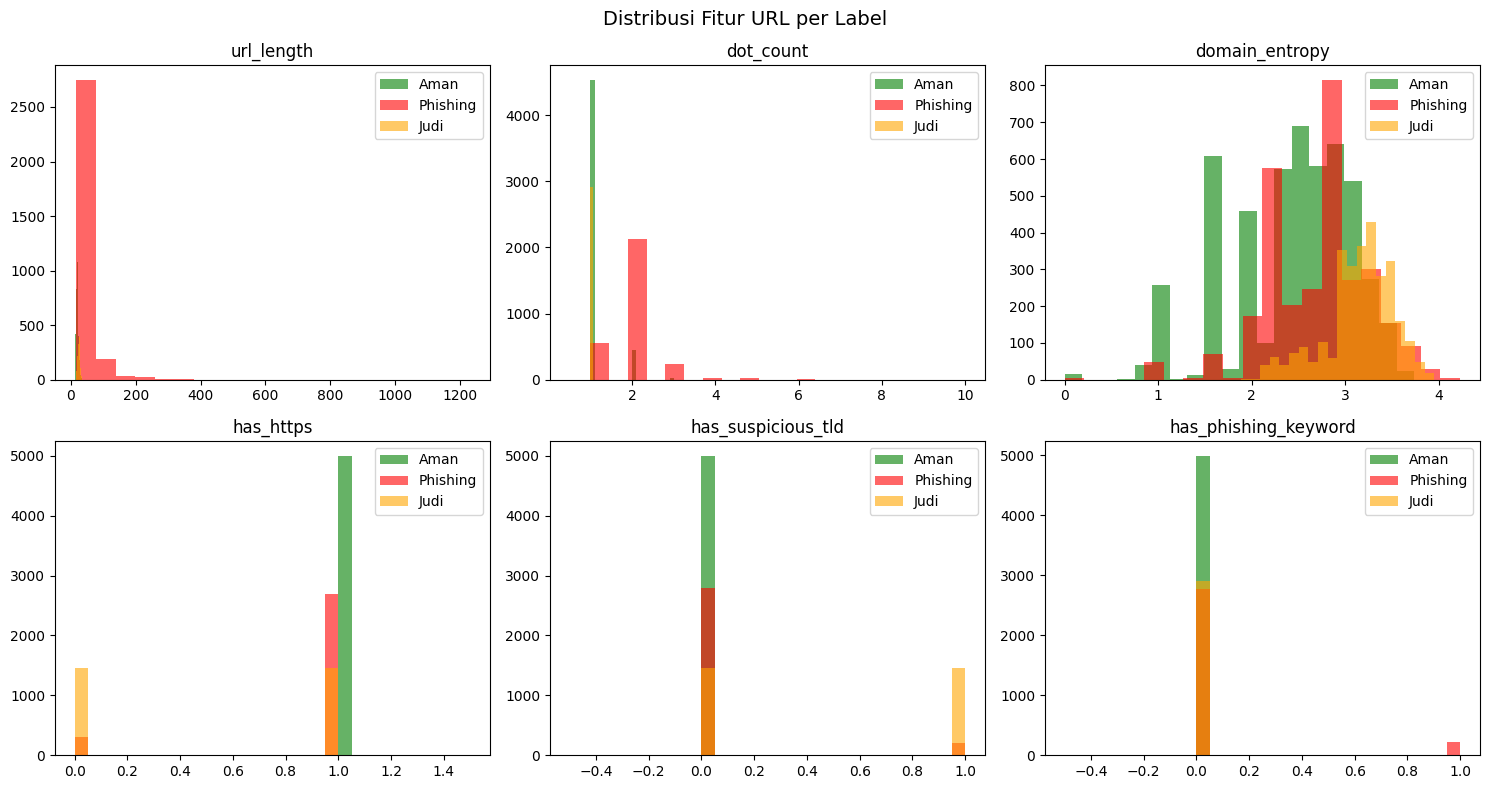

Grafik disimpan!


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Fitur URL per Label', fontsize=14)

label_names = {0: 'Aman', 1: 'Phishing', 2: 'Judi'}
colors      = {0: 'green', 1: 'red', 2: 'orange'}

fitur_plot = ['url_length', 'dot_count', 'domain_entropy',
              'has_https', 'has_suspicious_tld', 'has_phishing_keyword']

for idx, fitur in enumerate(fitur_plot):
    ax = axes[idx // 3][idx % 3]
    
    for label, nama in label_names.items():
        data = df_features[df_features['label'] == label][fitur]
        ax.hist(data, alpha=0.6, label=nama,
                color=colors[label], bins=20)
    
    ax.set_title(fitur)
    ax.legend()

plt.tight_layout()
plt.savefig('../dataset/feature_distribution.png', dpi=100)
plt.show()
print("Grafik disimpan!")